# 作业三：测量的Bloch球表示

In [1]:
###### -- QUANTA -- #######
# Author: Y. Liu, W. Shi  #
# Data: 2022-09-17        #
###########################

from qutip import *
from scipy.linalg import *
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

## 第一步：测量算符的测量基

给定任意的厄米算符，求其测量基

In [2]:
def getBasisState(O):
    psi_0 = np.matrix([[1.0000],[0.0000]], dtype = complex)
    psi_1 = np.matrix([[0.0000],[1.0000]], dtype = complex)
    #######################################
    #todo: modify the following code to complete this function. The initial values are assigned manually. Base vector with larger eigen values are listed ahead. i.e. eig_v[0] > eig_v[1]
    
    
    #######################################
    # order: eigenvalue(psi_0) > eivenvalue(psi_1)
    return [psi_0, psi_1]

def Meas(psi, O):
    m_base = getBasisState(O)
    p0 = 0.5000
    p1 = 0.5000
    #######################################
    #todo: modify the following code to complete this function. The initial values are assigned manually
    p0 = (abs(m_base[0].H * psi)**2)[0,0]
    p1 = (abs(m_base[1].H * psi)**2)[0,0]
    #######################################
    return [p0, p1]

### 测试代码：

In [3]:
#don't modify the code in this block
H_ck = np.matrix([[1.0170 + 0.0000j, 1.3284 + 0.4330j],
                  [1.3284 - 0.4330j, 1.5897 + 0.0000j]], dtype = complex)
psi_ck = np.matrix([[0.7337 + 0.0000j],[0.5213 + 0.4358j]], dtype = complex)

def checkBasisState():
    err = 0.0000 # used to accumulated all the errors
    print("Check the obtained basis state...")
    psi = getBasisState(H_ck)

    # check the orthogonality
    err = abs(psi[0].H * psi[0] - 1) + abs(psi[1].H * psi[0]) + abs(psi[0].H * psi[1]) + abs(psi[1].H * psi[1] - 1)

    # check if eigenstate
    psi_0 = H_ck * psi[0]
    err = err + np.real(1 - abs(psi_0.H*psi[0]/(norm(psi_0)*norm(psi[0]))))

    psi_1 = H_ck * psi[1]
    err = err + np.real(1 - abs(psi_1.H*psi[1]/(norm(psi_1)*norm(psi[1]))))

    if err < 0.01:
        print('Pass!')
    else:
        print('Wrong Answer err = %.3f! Please Correct the code.' % err)
        

def checkProb():
    print("Check the obtained probabilities...")

    p = Meas(psi_ck, H_ck)

    err = abs(p[0] - 0.7515) + abs(p[1] - 0.2485)
    if err < 0.01:
        print('Pass!')
    else:
        print('Wrong Answer err = %.3f! Please Correct the code.' % err)
    return

checkBasisState()
checkProb()

Check the obtained basis state...
Wrong Answer err = 0.660! Please Correct the code.
Check the obtained probabilities...
Wrong Answer err = 0.426! Please Correct the code.


## 第二步：测量的Bloch球表示

将测量的含义绘制在Bloch球上。修改代码完成绘制。
注意：
* make_sphere函数会将add_points/add_vectors体现在Bloch球上，如果需要再在Bloch球上绘制内容，需要在make_sphere函数之后再通过plot函数绘制。
* sphere的坐标系与plt.plot()函数的坐标系有所不同。函数plotLine()中有所体现。


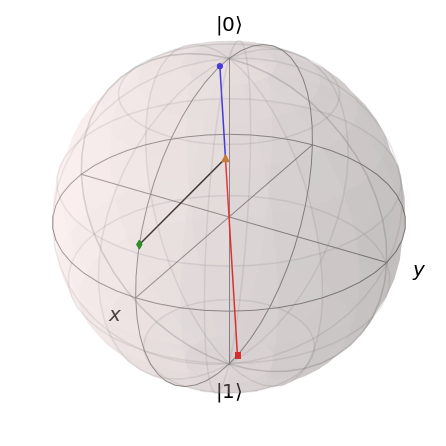

In [13]:
def plotLine(point1, point2, config):
    plt.plot([point1[1], point2[1]], [-point1[0], -point2[0]], [point1[2], point2[2]], config)

fig = plt.figure(figsize=(6,6))
axes = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(axes)
sphere = Bloch(axes = axes)

#example:

#coordinates of given basis states
coord0 = np.array([  0.0995,  0.0000,  0.9950], dtype = float)
coord1 = np.array([ -0.0995, -0.0000, -0.9950], dtype = float)
psi_ex_coord = np.array([0.9518, 0.0000, 0.3068], dtype = float)
#probabilities are:
p = [0.3, 0.7]
coord_projection = p[0] * coord1 + p[1] * coord0

sphere.add_points(coord0)
sphere.add_points(coord1)
sphere.add_points(psi_ex_coord)
sphere.add_points(coord_projection)

######################
#todo: plot the two basis states of H, and the probability of psi on H.
H = np.matrix([[2**(-0.5), 2**(-0.5)], [2**(-0.5), -2**(-0.5)]], dtype=complex)
psi = np.matrix([[3**(-0.5)],[(2/3)**(0.5) * 1j]], dtype=complex)








######################
sphere.make_sphere()

#example
# Plot by 'plt' have to be called after 'make_sphere()'
plotLine(coord_projection, psi_ex_coord, '-k')
plotLine(coord_projection, coord0, '-b')
plotLine(coord_projection, coord1, '-r')
######################
#todo: plot the line corresponding to the probabilities of measurement.


######################